In [1]:
# !pip install numpy scipy matplotlib seaborn scikit-learn mesa==3.5 -q

# Robots Limpiadores

En un espacio representado por una cuadrícula de tamaño NxN, cada celda puede estar limpia o sucia. En este entorno, operan varias barredoras eléctricas, que son agentes autónomos responsables de limpiar la cuadrícula. Estas barredoras pueden moverse en las ocho direcciones cardinales: arriba, abajo, izquierda, derecha y las cuatro diagonales.

Cada barredora tiene las siguientes capacidades:
* **Detección:** Puede detectar si la celda donde está limpia o sucia.
* **Limpieza:** Puede limpiar la celda en la que se encuentra.
* **Movimiento:** Puede moverse a una celda adyacente si esta no está ocupada por otra barredora.
* **Posición de arranque:** Todas las celdas en posiciones al azar.

El desafío es desarrollar un sistema multiagentes que limpie la cuadrícula de la manera más eficiente posible. Definimos eficiencia como la relación entre el número de celdas limpiadas y el número de celdas recorridas por un agente.

In [1]:
# Requiere Mesa == 3.5
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''SingleGrid''.
from mesa.space import SingleGrid

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

# Importamos esta librería para generar numeros aleatorios más adelante
import sys

In [2]:
class Stack:
    def __init__(self):
        self.__data = []

    def empty(self):
        return not self.__data

    def clear(self):
        self.__data.clear()

    def push(self, element):
        self.__data.append(element)

    def pop(self):
        if self.__data: # not empty
            self.__data.pop()
        else:
            raise Exception("No such element")

    def top(self):
        if self.__data: # not empty
            return self.__data[-1]
        else:
            raise Exception("No such element")

    def display(self):
        print(self.__data)

In [3]:
class RobotSweep(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.cells_cleaned = 0
        self.cells_visited = 1
        self.previous_steps = Stack()

    def move(self):
        possible_positions = self.model.grid.get_neighborhood(self.pos, moore=False, include_center=False)
        options = np.random.permutation(len(possible_positions))

        hasMove = False
        for i in options:
            position = possible_positions[i]
            (x, y) = position
            if self.model.grid.is_cell_empty(position) and self.model.visited_cells[x][y] == 0:
                self.previous_steps.push(self.pos)
                self.model.grid.move_agent(self, position)
                self.cells_visited += 1
                self.model.visited_cells[x][y] = 1
                hasMove = True
                break

        if not hasMove:
            if self.previous_steps.empty():
                return

            position = self.previous_steps.top()
            if self.model.grid.is_cell_empty(position):
                self.previous_steps.pop()
                self.model.grid.move_agent(self, position)
                self.cells_visited += 1

    def step(self):
        if self.model.is_all_clean():
            return

        (x, y) = self.pos
        if self.model.cells[x][y] == 1:
            self.model.cells[x][y] = 0
            self.cells_cleaned += 1
        else:
            self.move()

In [4]:
def get_grid(model):
    grid = np.zeros( (model.grid.width, model.grid.height) )
    for content, (x, y) in model.grid.coord_iter():
        grid[x][y] = model.cells[x][y]
        if content != None:
            grid[x][y] = 2
    return grid

In [16]:
class RobotSweepModel(Model):
    def __init__(self, width=20, height=20, agents=5, percentage_dirty_cells=10, **kwargs):
        super().__init__()

        self.count_steps = 0

        self.grid = SingleGrid(width, height, torus=False)

        self.visited_cells = np.zeros( (width, height) )

        self.cells = np.zeros( (width, height) )
        count = int( (width * height * (percentage_dirty_cells / 100)) )
        while (count > 0):
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.cells[x][y] == 0:
                self.cells[x][y] = 1
                count -= 1
                
        i = 0
        while (i < agents):
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.grid.is_cell_empty( (x, y) ):
                agent = RobotSweep(self)
                self.grid.place_agent(agent, (x, y))
                self.agents.add(agent)
                i += 1

        self.datacollector = DataCollector(
            model_reporters={"Grid":get_grid,
                             "Steps":lambda model : model.count_steps,
                             "Clean":lambda model : 1 - (model.cells.sum() / model.cells.size)},
            agent_reporters={"Efficiency":lambda agent : agent.cells_cleaned / agent.cells_visited})

    def step(self):
        if not(self.is_all_clean()):
            self.count_steps += 1
        
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

    def is_all_clean(self):
        return (self.cells.sum() == 0)

In [17]:
# Registramos el tiempo de inicio y ejecutamos la simulación
model = RobotSweepModel()#
#for i in range(1000):
while not(model.is_all_clean()):
    model.step()

In [18]:
all_agents_info = model.datacollector.get_agent_vars_dataframe()
all_agents_info.info()

<class 'pandas.DataFrame'>
MultiIndex: 1060 entries, (np.float64(1.0), np.int64(1)) to (np.float64(212.0), np.int64(5))
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Efficiency  1060 non-null   float64
dtypes: float64(1)
memory usage: 13.2 KB


In [19]:
# Obtenemos la información que almacenó el colector, este nos entregará un DataFrame de pandas que contiene toda la información.
all_grids = model.datacollector.get_model_vars_dataframe()
all_grids.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Grid    212 non-null    object 
 1   Steps   212 non-null    int64  
 2   Clean   212 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 5.1+ KB


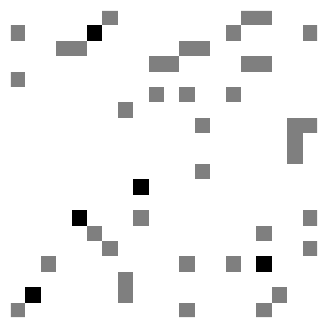

In [20]:
# Graficamos la información usando `matplotlib`
# %%capture

fig, axs = plt.subplots(figsize=(4,4))
axs.set_xticks([])
axs.set_yticks([])
patch = plt.imshow(all_grids.iloc[0, 0], cmap=plt.cm.binary)

def animate(i):
    patch.set_data(all_grids.iloc[i, 0])

anim = animation.FuncAnimation(fig, animate, frames=model.steps)

In [21]:
anim

In [22]:
params = {"width":20, "height":20, "agents":range(5, 25, 5), "percentage_dirty_cells":10}

MAX_STEPS = 3000

rng = np.random.default_rng(42)
rng_values = rng.integers(0, sys.maxsize, size=(5,))

results = batch_run(
    RobotSweepModel,
    parameters=params,
    rng=rng_values.tolist(),
    max_steps=MAX_STEPS,
    number_processes=1,
    data_collection_period=1,
    display_progress=True,
)

  0%|          | 0/20 [00:00<?, ?it/s]

In [23]:
df = pd.DataFrame(results)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   RunId                   750000 non-null  int64  
 1   iteration               750000 non-null  int64  
 2   Step                    750000 non-null  float64
 3   width                   750000 non-null  int64  
 4   height                  750000 non-null  int64  
 5   agents                  750000 non-null  int64  
 6   percentage_dirty_cells  750000 non-null  int64  
 7   rng                     750000 non-null  int64  
 8   Grid                    750000 non-null  object 
 9   Steps                   750000 non-null  int64  
 10  Clean                   750000 non-null  float64
 11  AgentID                 750000 non-null  int64  
 12  Efficiency              750000 non-null  float64
dtypes: float64(3), int64(9), object(1)
memory usage: 74.4+ MB


## ¿Cómo influye el número de agentes en el número máximo de pasos requeridos para limpiar completamente el espacio?

In [24]:
resultado = (
    df.groupby(["RunId", "iteration", "agents"])["Steps"]
    .max()
    .reset_index()
)

promedios = (
    resultado.groupby("agents")["Steps"]
    .mean()
    .reset_index()
)

promedios

,agents,Steps
0,5,155.8
1,10,98.8
2,15,69.6
3,20,48.8


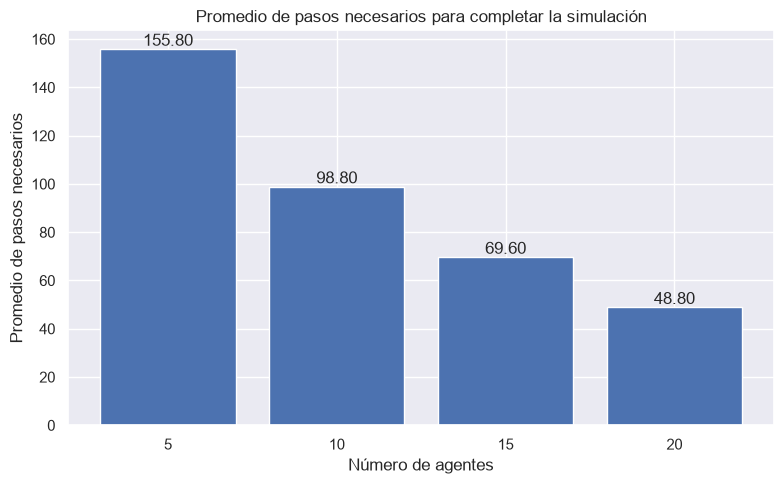

In [25]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    promedios["agents"].astype(str),
    promedios["Steps"]
)

plt.xlabel("Número de agentes")
plt.ylabel("Promedio de pasos necesarios")
plt.title("Promedio de pasos necesarios para completar la simulación")

for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        altura,
        f"{altura:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [26]:
resultado = (
    df[df["agents"] == 5]
    .groupby("iteration")["Steps"]
    .max()
    .reset_index()
)
resultado

,iteration,Steps
0,0,136
1,1,137
2,2,166
3,3,180
4,4,160


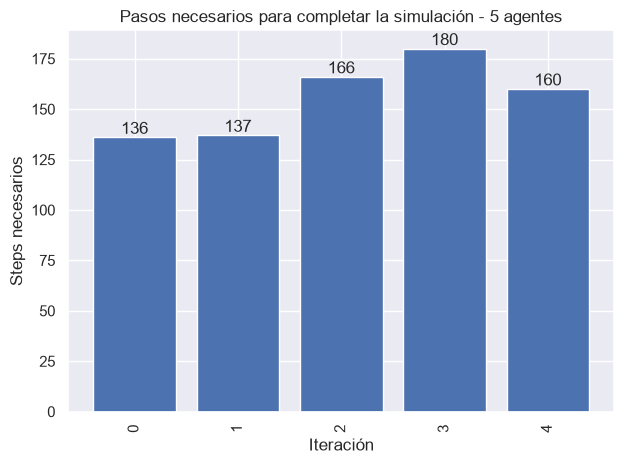

In [27]:
bars = plt.bar(
    resultado["iteration"].astype(str),
    resultado["Steps"]
)

plt.xlabel("Iteración")
plt.ylabel("Steps necesarios")
plt.title("Pasos necesarios para completar la simulación - 5 agentes")
plt.xticks(rotation=90)

for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        altura,
        f"{altura:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## ¿Qué efecto tiene el número de agentes sobre la eficiencia promedio de los agentes?

In [28]:
eficiencia_simulacion = (
    df.groupby(["RunId", "iteration", "agents"])["Efficiency"]
    .mean()
    .reset_index()
)

eficiencia_promedio = (
    eficiencia_simulacion.groupby("agents")["Efficiency"]
    .mean()
    .reset_index()
)

eficiencia_promedio

,agents,Efficiency
0,5,0.059478
1,10,0.057356
2,15,0.059998
3,20,0.059295


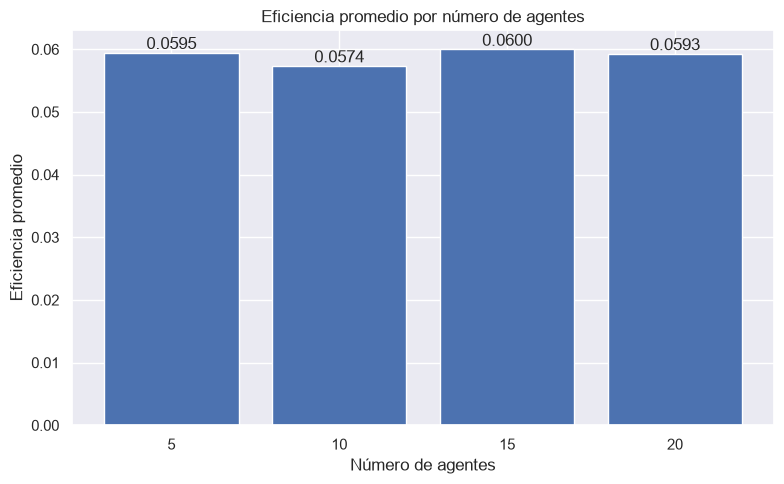

In [29]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    eficiencia_promedio["agents"].astype(str),
    eficiencia_promedio["Efficiency"]
)

plt.xlabel("Número de agentes")
plt.ylabel("Eficiencia promedio")
plt.title("Eficiencia promedio por número de agentes")

for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        altura,
        f"{altura:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [30]:
eficiencia_5 = (
    df[
        (df["agents"] == 5) &
        (df["Step"] <= df["Steps"])
    ]
    .groupby(["iteration", "AgentID"])["Efficiency"]
    .mean()
    .reset_index()
)

eficiencia_5.head(10)

,iteration,AgentID,Efficiency
0,0,1,0.050328
1,0,2,0.141190
2,0,3,0.098760
3,0,4,0.083938
4,0,5,0.115639
5,1,1,0.082330
6,1,2,0.085129
7,1,3,0.040634
8,1,4,0.037996
9,1,5,0.097848


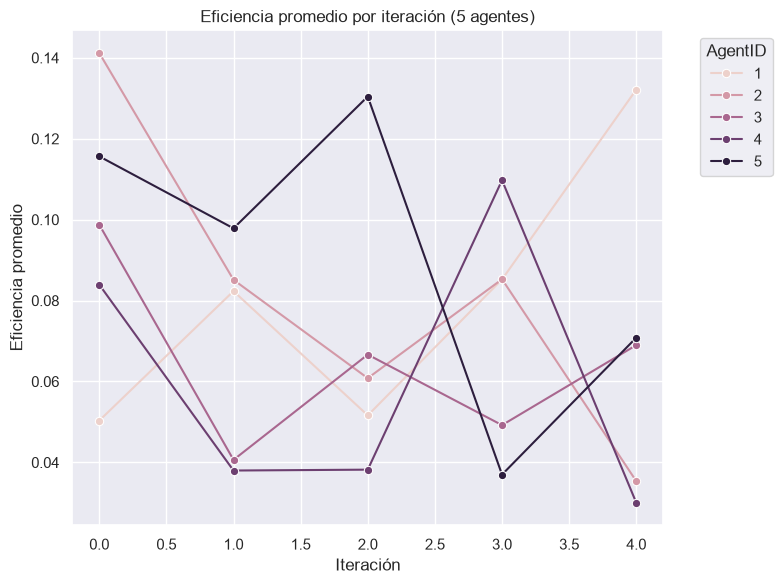

In [31]:
plt.figure(figsize=(8, 6))
sns.lineplot(
    data=eficiencia_5,
    x="iteration",
    y="Efficiency",
    hue="AgentID",
    marker="o"
)
plt.title("Eficiencia promedio por iteración (5 agentes)")
plt.xlabel("Iteración")
plt.ylabel("Eficiencia promedio")
plt.legend(title="AgentID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

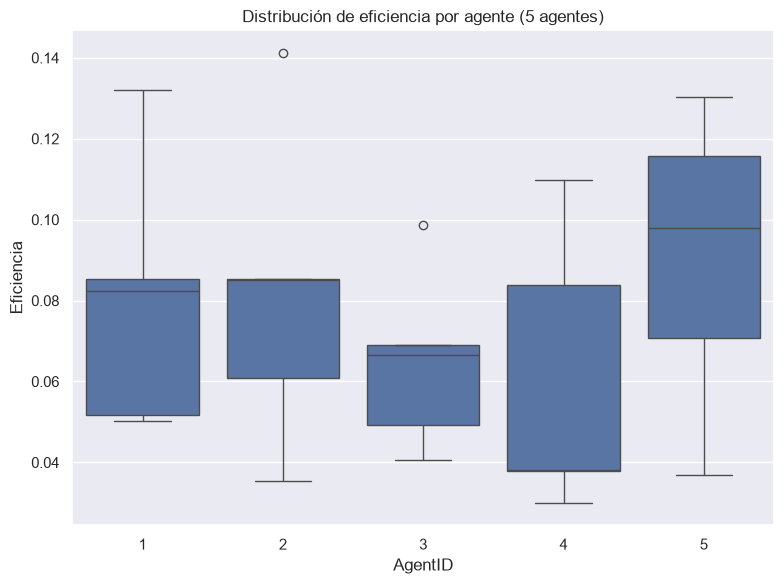

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=eficiencia_5,
    x="AgentID",
    y="Efficiency"
)
plt.title("Distribución de eficiencia por agente (5 agentes)")
plt.xlabel("AgentID")
plt.ylabel("Eficiencia")
plt.tight_layout()
plt.show()